# Linear Regression Baseline

**Status:** In progress

Work through the sections in order. Fill in each `TODO` cell, run it, and write a short answer before moving to the next section. This notebook uses scikit-learn's built-in diabetes dataset, so no download is needed.

Related note: [`ai-docs/docs/ml/linear-regression.md`](../ai-docs/docs/ml/linear-regression.md)

## 1. Setup

**Question:** What library will you use for tabular data, plotting, splitting data, modelling, and metrics?

In [1]:
# TODO: import numpy, pandas, matplotlib.pyplot, and the scikit-learn tools you need.
# Suggested tools: load_diabetes, train_test_split, LinearRegression,
# mean_absolute_error, mean_squared_error, r2_score

import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn

## 2. Load and inspect the data

**Questions:**

1. How many rows and feature columns are in the dataset?
2. What does the target represent?
3. Which feature has the strongest positive and negative correlation with the target?

In [2]:
# TODO: load the diabetes dataset and make a DataFrame named df.
# Add the target as a column named 'target'.
# Then inspect df with head(), shape, describe(), and corr().

dataset = sklearn.datasets.load_diabetes()
dataset.feature_names
# 10 rows and feature columns are in the dataset. The target is the disease progression after one year.

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [3]:
df, target = sklearn.datasets.load_diabetes(return_X_y=True, as_frame=True)
df['target'] = target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.shape
# ANS: total 442 rows and 10 columns

(442, 11)

In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
df.corr()
# bmi has the strongest correlation and S3 has the weakest correlation with the target. The correlation is positive for bmi and negative for S3.

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


Write your answers here:

- Rows and features: 442 x 10
- Target: Target represents the progression of diabetes from baseline in a year
- Strongest positive correlation: bmi
- Strongest negative correlation: s5

## 3. Create a holdout test set

Use an 80/20 split and `random_state=42`.

**Questions:** Why must the test set be separated before fitting the model? What could go wrong if you repeatedly made choices after looking at its score?

In [7]:
# TODO: create X and y, then split them into X_train, X_test, y_train, y_test.
# Print the shapes of all four arrays.

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


Your answer: We Will be testing the model with the same data it is trained on so the outcome will be more close than it actually is

## 4. Establish a baseline

A useful baseline predicts the training-set mean for every test example.

**Question:** What do MAE and RMSE measure? Why is RMSE usually more affected by large mistakes?

In [8]:
# TODO: make baseline_predictions using the mean of y_train.
# Calculate and print baseline MAE and RMSE on y_test.
# Hint: np.full(y_test.shape, y_train.mean()) can create repeated predictions.

baseline_predictions = np.full(y_test.shape, y_train.mean())
baseline_mae = sklearn.metrics.mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_test, baseline_predictions))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 64.00646146990485
Baseline RMSE: 73.22249283682244


Your answer: Both MAE ans RMSE are measures of error for a learning algorithm. RMSE square the error so it is more affected by the outliar.

## 5. Train a linear-regression model

Fit `LinearRegression` using only the training set.

**Question:** In the expression $h_\theta(x) = \theta^T x$, what do `coef_` and `intercept_` correspond to?

In [9]:
# TODO: create, fit, and use a LinearRegression model.
# Store its test-set predictions in y_pred.

linear_model = sklearn.linear_model.LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)


Your answer: If the learned function is y = mx + c then m is the coef_ and c is the intercept_

## 6. Evaluate and compare

Calculate MAE, RMSE, and $R^2$ for the linear-regression model. Compare the results with your baseline.

**Questions:**

1. Did the model beat the baseline on both error metrics?
2. What does your $R^2$ value say about the proportion of variance explained on this test split?
3. Is a good test score proof that the model will work well for every future patient? Why not?

In [10]:
# TODO: calculate model_mae, model_rmse, and model_r2.
# Print a compact comparison of baseline and model metrics.
# Hint: set squared=False only if your installed scikit-learn version supports it.

model_mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
model_rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_test, y_pred))
model_r2 = sklearn.metrics.r2_score(y_test, y_pred) 

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Model MAE: {model_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Model RMSE: {model_rmse:.4f}")
print(f"Model R^2: {model_r2:.4f}")

Baseline MAE: 64.0065
Model MAE: 42.7941
Baseline RMSE: 73.2225
Model RMSE: 53.8534
Model R^2: 0.4526


Write your answers here:

1. Yes
2. R2 value explains about 45% of the variation and remaining 55% are not explained by this linear model and its then input features
3. No. It is not a proof that it will work well for future patient future patients may differ from the training data, measurements may be noisy and the model may miss important factors. Also the R2 score explains that there is scope of improvement in terms of prediction.

## 7. Inspect coefficients and errors

**Questions:**

1. Which three features have the largest coefficient magnitude?
2. Which prediction has the largest absolute residual?
3. Does a positive coefficient prove that changing that feature causes the target to increase?

In [11]:
# TODO: create a coefficient table with feature names and coefficients.
# Sort it by absolute coefficient magnitude.
# Create a residuals table with actual values, predictions, and residuals.
# Find the row with the largest absolute residual.


coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': linear_model.coef_})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

residuals = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
residuals['Residual'] = residuals['Actual'] - residuals['Predicted']
largest_residual_row = residuals.loc[residuals['Residual'].abs().idxmax()]

print("Coefficients Table:")
print(coefficients)
print("\nResiduals Table:")
print(residuals)
print("\nRow with Largest Absolute Residual:")
print(largest_residual_row)


Coefficients Table:
  Feature  Coefficient  Abs_Coefficient
4      s1  -931.488846       931.488846
8      s5   736.198859       736.198859
2     bmi   542.428759       542.428759
5      s2   518.062277       518.062277
3      bp   347.703844       347.703844
7      s4   275.317902       275.317902
1     sex  -241.964362       241.964362
6      s3   163.419983       163.419983
9      s6    48.670657        48.670657
0     age    37.904021        37.904021

Residuals Table:
     Actual   Predicted    Residual
287   219.0  139.547558   79.452442
211    70.0  179.517208 -109.517208
72    202.0  134.038756   67.961244
321   230.0  291.417029  -61.417029
73    111.0  123.789659  -12.789659
..      ...         ...         ...
255   153.0  115.011800   37.988200
90     98.0   78.955842   19.044158
57     37.0   81.560873  -44.560873
391    63.0   54.379973    8.620027
24    184.0  166.254352   17.745648

[89 rows x 3 columns]

Row with Largest Absolute Residual:
Actual        52.000000
Predic

Write your answers here:

1. S1, S5 and bmi
2. The largest absolute residual is at test-set row/index 56:- Actual: 52
- Predicted: 206.49
- Residual: actual − predicted = 52 − 206.49 = −154.49
- Absolute residual: |-154.49| = 154.49
3. No. A positive coefficient shows an association in this fitted model: holding the other input features constant, higher values of that feature are associated with a higher predicted target.

## 8. Visualize residuals

Make a scatter plot of predicted values against residuals. Add a horizontal line at zero.

**Questions:** What pattern would make you question the linear-model assumption? What pattern would suggest that the error variance changes with the prediction?

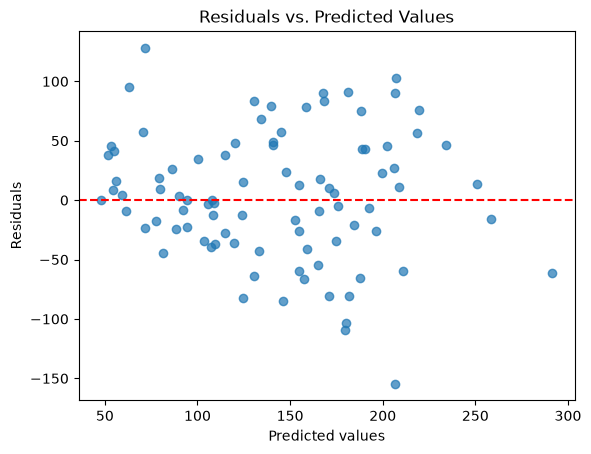

In [12]:
# TODO: plot y_pred on the x-axis and residuals on the y-axis.
# Label both axes and add a y=0 reference line.

plt.scatter(y_pred, residuals['Residual'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()



Your answer: 

## 9. Challenge

Choose one extension:

- Train the model with only the single feature most correlated with the target and compare its metrics.
- Change `random_state` to three different values. How stable are the scores?
- Implement batch gradient descent in NumPy and compare its learned parameters with scikit-learn's result.

Record what you tried and what you learned below.

In [13]:
# TODO: implement one challenge.



## Reflection

- What felt clear?
- What was confusing?
- What will you study next?